<a href="https://colab.research.google.com/github/tumatidurga/collab/blob/main/braintumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

**Loading** **Dataset**

In [5]:
from google.colab import files

uploaded = files.upload()

Saving 1 no.jpeg to 1 no.jpeg
Saving 2 no.jpeg to 2 no.jpeg
Saving 3 no.jpg to 3 no.jpg
Saving 4 no.jpg to 4 no.jpg
Saving 5 no.jpg to 5 no.jpg
Saving 6 no.jpg to 6 no.jpg
Saving 7 no.jpg to 7 no.jpg
Saving 8 no.jpg to 8 no.jpg
Saving 9 no.jpg to 9 no.jpg
Saving 10 no.jpg to 10 no.jpg
Saving 11 no.jpg to 11 no.jpg
Saving 12 no.jpg to 12 no.jpg
Saving 13 no.jpg to 13 no.jpg
Saving 14 no.jpg to 14 no.jpg
Saving 15 no.jpg to 15 no.jpg
Saving 17 no.jpg to 17 no.jpg
Saving 18 no.jpg to 18 no.jpg
Saving 19 no.jpg to 19 no.jpg
Saving 20 no.jpg to 20 no.jpg
Saving 21 no.jpg to 21 no.jpg
Saving 22 no.jpg to 22 no.jpg
Saving 23 no.jpg to 23 no.jpg
Saving 24 no.jpg to 24 no.jpg
Saving 25 no.jpg to 25 no.jpg
Saving 26 no.jpg to 26 no.jpg
Saving 27 no.jpg to 27 no.jpg
Saving 28 no.jpg to 28 no.jpg
Saving 29 no.jpg to 29 no.jpg
Saving 30 no.jpg to 30 no.jpg
Saving 31 no.jpg to 31 no.jpg
Saving 32 no.jpg to 32 no.jpg
Saving 33 no.jpg to 33 no.jpg
Saving 34 no.jpg to 34 no.jpg
Saving 35 no.jpg to 35 n

In [8]:
print(uploaded.keys())

dict_keys(['1 no.jpeg', '2 no.jpeg', '3 no.jpg', '4 no.jpg', '5 no.jpg', '6 no.jpg', '7 no.jpg', '8 no.jpg', '9 no.jpg', '10 no.jpg', '11 no.jpg', '12 no.jpg', '13 no.jpg', '14 no.jpg', '15 no.jpg', '17 no.jpg', '18 no.jpg', '19 no.jpg', '20 no.jpg', '21 no.jpg', '22 no.jpg', '23 no.jpg', '24 no.jpg', '25 no.jpg', '26 no.jpg', '27 no.jpg', '28 no.jpg', '29 no.jpg', '30 no.jpg', '31 no.jpg', '32 no.jpg', '33 no.jpg', '34 no.jpg', '35 no.jpg', '36 no.jpg', '37 no.jpg', '38 no.jpg', '39 no.jpg', '40 no.jpg', '41 no.jpg', '42 no.jpg', '43 no.jpg', '44no.jpg', '45 no.jpg', '46 no.jpg', '47 no.jpg', '48 no.jpeg', '49 no.jpg', '50 no.jpg', 'N1.JPG', 'N2.JPG', 'N3.jpg', 'N5.jpg', 'N6.jpg', 'N11.jpg', 'N15.jpg', 'N16.jpg', 'N17.jpg', 'N19.JPG', 'N20.JPG', 'N21.jpg', 'N22.JPG', 'N26.JPG', 'no 1.jpg', 'no 2.jpg', 'no 3.jpg', 'no 4.jpg', 'no 5.jpeg', 'no 6.jpg', 'no 7.jpeg', 'no 8.jpg', 'no 9.png', 'no 10.jpg', 'no 89.jpg', 'no 90.jpg', 'no 91.jpeg', 'no 92.jpg', 'no 94.jpg', 'no 95.jpg', 'no 96.j

In [9]:
import os

images = os.listdir()

print("Total Images:", len(images))

Total Images: 101


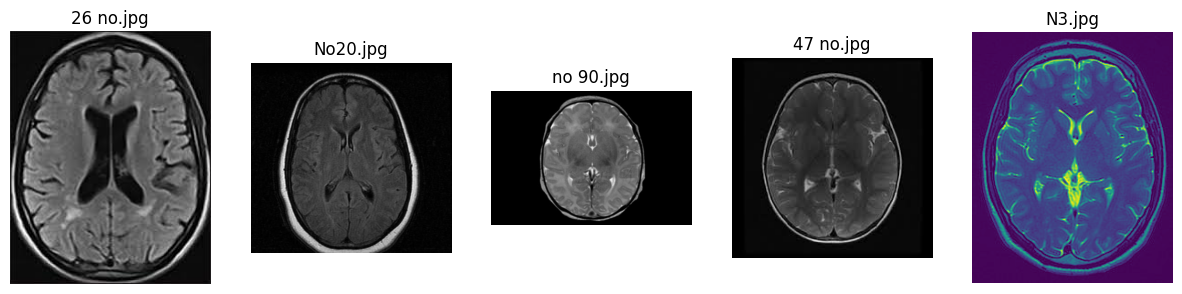

In [10]:
from PIL import Image
import matplotlib.pyplot as plt
import random

sample = random.sample(os.listdir(),5)

plt.figure(figsize=(15,5))

for i,file in enumerate(sample):

    img = Image.open(file)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(file)
    plt.axis("off")

plt.show()

In [12]:
import pandas as pd
import os

data = []

for file in os.listdir():

    if file.lower().endswith(('.jpg','.jpeg','.png')):

        if file.startswith("N"):
            label = 1
        else:
            label = 0

        data.append([file,label])

df = pd.DataFrame(data,
                  columns=["Image","Label"])

df.head(101)

,Image,Label
0,N26.JPG,1
1,No13.jpg,1
2,No16.jpg,1
3,38 no.jpg,0
4,N5.jpg,1
...,...,...
93,41 no.jpg,0
94,44no.jpg,0
95,1 no.jpeg,0
96,No14.jpg,1


**Dataset** **Information**

In [13]:
print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nClass Distribution:")
print(df['Label'].value_counts())

Dataset Shape:
(98, 2)

First 5 Rows:


,Image,Label
0,N26.JPG,1
1,No13.jpg,1
2,No16.jpg,1
3,38 no.jpg,0
4,N5.jpg,1



Class Distribution:
Label
0    72
1    26
Name: count, dtype: int64


In [32]:
print("Class Counts:")
print(df['Label'].value_counts())

print("\nClass Percentage:")
print(
    round(
        df['Label'].value_counts(normalize=True) * 100,
        2
    )
)

Class Counts:
Label
0    72
1    26
Name: count, dtype: int64

Class Percentage:
Label
0    73.47
1    26.53
Name: proportion, dtype: float64


**Visualize** **Class** **Distribution**

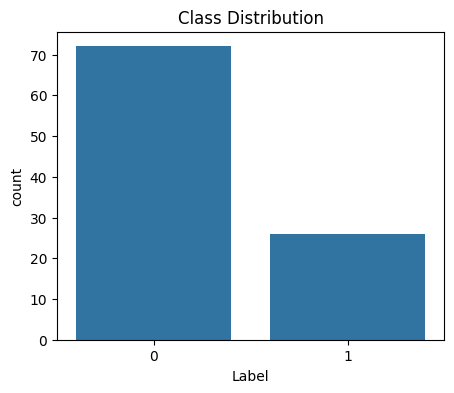

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.countplot(x=df['Label'])

plt.title("Class Distribution")

plt.show()

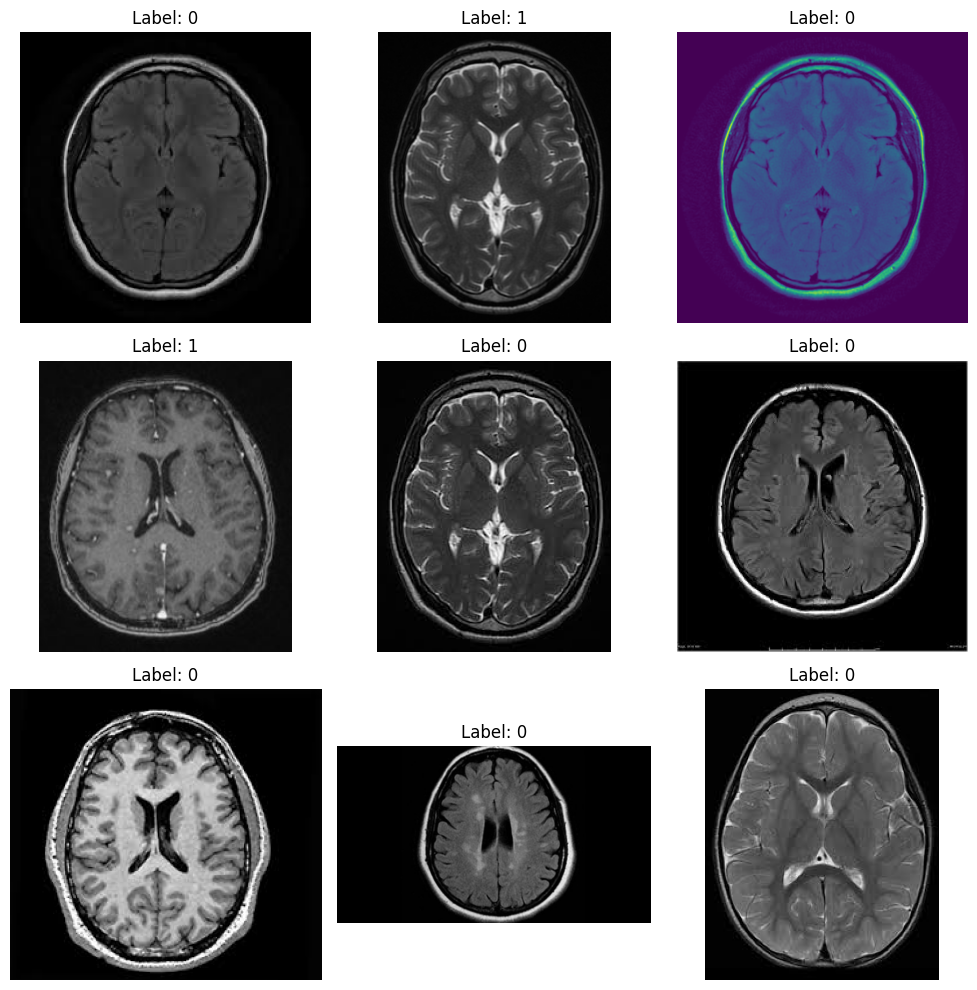

In [33]:
import random
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for i in range(9):

    idx = random.randint(0, len(df)-1)

    img = Image.open(df.iloc[idx]['Image'])

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(f"Label: {df.iloc[idx]['Label']}")

    plt.axis('off')

plt.tight_layout()

plt.show()

**Check for Corrupted Images**

In [15]:
from PIL import Image

corrupted = []

for file in df['Image']:

    try:
        img = Image.open(file)
        img.verify()

    except:
        corrupted.append(file)

print("Corrupted Images:")
print(corrupted)

print("Total Corrupted Images:", len(corrupted))

Corrupted Images:
[]
Total Corrupted Images: 0


**Check Image Sizes**

In [16]:
from PIL import Image

sizes = []

for file in df['Image']:

    img = Image.open(file)

    sizes.append(img.size)

print("Sample Sizes:")

for size in sizes[:10]:
    print(size)

Sample Sizes:
(210, 264)
(442, 442)
(300, 200)
(201, 251)
(201, 250)
(218, 231)
(300, 168)
(220, 275)
(236, 213)
(232, 217)


**Resize** **Images**

In [17]:
from PIL import Image
import numpy as np

X = []

for file in df['Image']:

    img = Image.open(file)

    img = img.convert("RGB")

    img = img.resize((128,128))

    img = np.array(img)

    X.append(img)

X = np.array(X)

print(X.shape)

(98, 128, 128, 3)


In [51]:
print("Fresh X max:", X.max())
print("Fresh X min:", X.min())

Fresh X max: 255
Fresh X min: 0


In [40]:
print(X.shape)

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

(98, 128, 128, 3)
Minimum pixel value: 0
Maximum pixel value: 255


**Prepare Labels**

In [18]:
y = df['Label'].values

print(y.shape)

(98,)


**Train-Test Split**

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(78, 128, 128, 3)
(20, 128, 128, 3)


In [54]:
print("After fresh split")
print("X_train max:", X_train.max())
print("X_test max:", X_test.max())

After fresh split
X_train max: 255
X_test max: 255


**Normalize Images**

In [55]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("After normalization")
print("X_train max:", X_train.max())
print("X_test max:", X_test.max())

After normalization
X_train max: 1.0
X_test max: 1.0


**Build CNN Model**

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [57]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(
    MaxPooling2D((2,2))
)

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(
    MaxPooling2D((2,2))
)

model.add(Flatten())

model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

**View Model Structure**

In [58]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

**Compile Model**

In [59]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

**Train Model**

In [60]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test,y_test)
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 443ms/step - accuracy: 0.7179 - loss: 1.5354 - val_accuracy: 0.4500 - val_loss: 0.8349
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 405ms/step - accuracy: 0.5256 - loss: 0.7183 - val_accuracy: 0.3000 - val_loss: 0.7182
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 370ms/step - accuracy: 0.7692 - loss: 0.5885 - val_accuracy: 0.7500 - val_loss: 0.6401
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 401ms/step - accuracy: 0.7308 - loss: 0.5287 - val_accuracy: 0.7500 - val_loss: 0.6374
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 404ms/step - accuracy: 0.7308 - loss: 0.5121 - val_accuracy: 0.7500 - val_loss: 0.6527
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 557ms/step - accuracy: 0.7308 - loss: 0.4740 - val_accuracy: 0.7000 - val_loss: 0.6697
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 377ms/step - accuracy: 0.7692 - loss: 0.4351 - val_accuracy: 0.5000 - val_loss: 0.7010
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 381ms/step - accuracy: 0.8462 - loss: 0.3975 - val_accuracy: 0.5000 - val_loss:

**Evaluate Model**

In [61]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.5500 - loss: 0.6784
Accuracy: 0.550000011920929


**Plot Accuracy Graph**

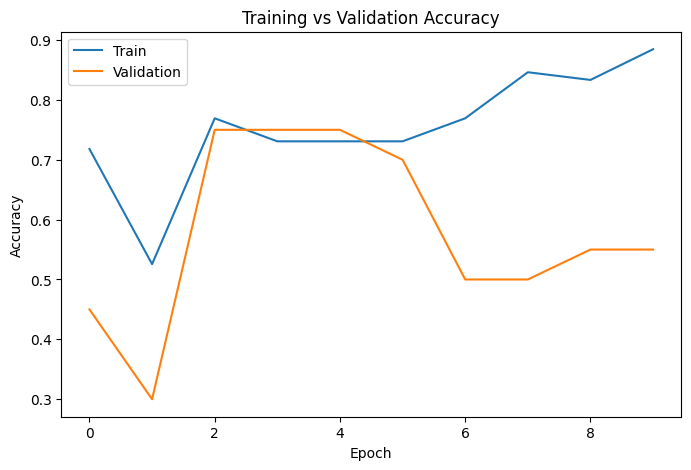

In [62]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

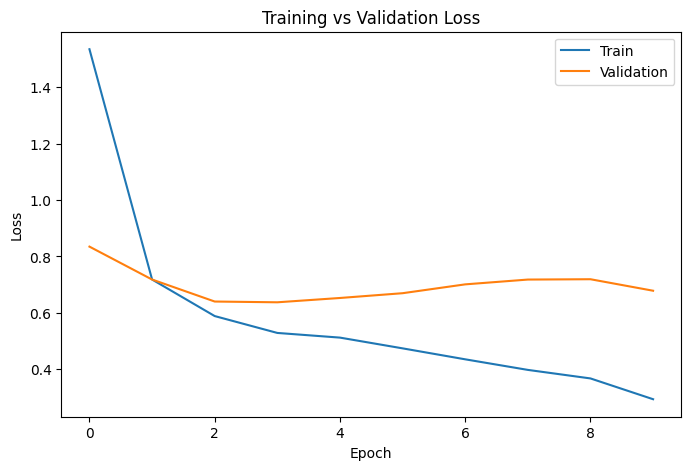

In [63]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(['Train','Validation'])

plt.show()

**Predictions**

In [64]:
predictions = model.predict(X_test)

predictions = (predictions > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


**Confusion Matrix**

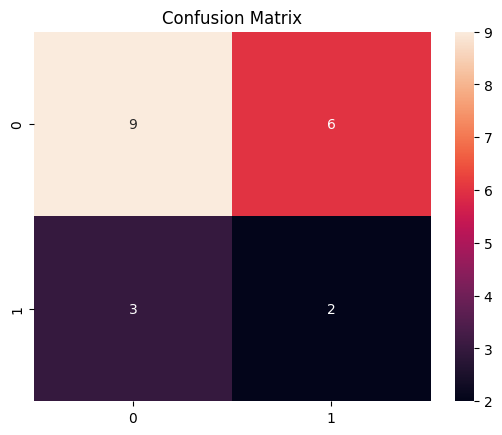

In [65]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()

**Classification Report**

In [66]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.75      0.60      0.67        15
           1       0.25      0.40      0.31         5

    accuracy                           0.55        20
   macro avg       0.50      0.50      0.49        20
weighted avg       0.62      0.55      0.58        20



In [67]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

print("Precision :", round(precision_score(y_test, predictions), 4))

print("Recall    :", round(recall_score(y_test, predictions), 4))

print("F1 Score  :", round(f1_score(y_test, predictions), 4))

Precision : 0.25
Recall    : 0.4
F1 Score  : 0.3077


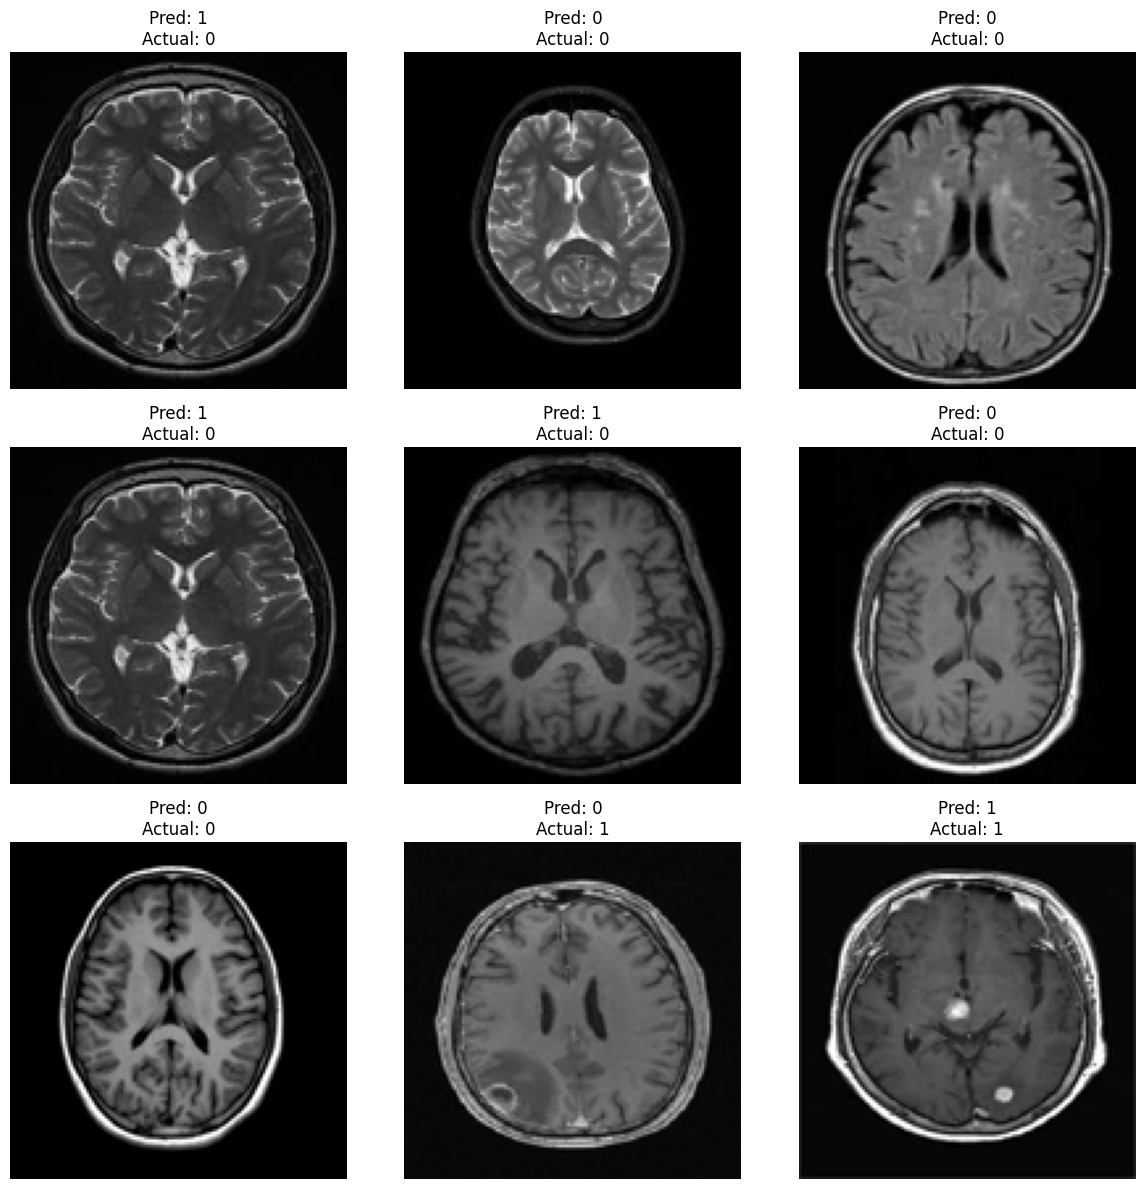

In [68]:
import random
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,12))

for i in range(9):

    idx = random.randint(0, len(X_test)-1)

    plt.subplot(3,3,i+1)

    img = (X_test[idx] * 255).astype(np.uint8)

    plt.imshow(img)

    pred = int(predictions[idx])
    actual = int(y_test[idx])

    plt.title(
        f"Pred: {pred}\nActual: {actual}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()